<a href="https://colab.research.google.com/github/IsaacBFine/diabetes-predictors/blob/main/Notebooks/plsr_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PLSR Notebook
LASSO gave us a good baseline by indicating which variables held predictive power independent of other variables. However, based on our prior knowledge, we expected that there would exist interactions between the indicators themselves and wanted to explore that further using PLSR.




In [6]:
import pandas as pd

url = "https://raw.githubusercontent.com/IsaacBFine/diabetes-predictors/refs/heads/main/Data/clean/diabetes_binary_5050split_health_indicators_BRFSS2015.csv"

data = pd.read_csv(url)
data.head()
#Loads in dataset


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


In [10]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import cross_val_score
import numpy as np
import matplotlib.pyplot as plt
import random
random.seed(67)
import numpy as np
np.random.seed(67)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [11]:
#Split data into indicators and diabetes outcome.

X = data.drop(columns = ["Diabetes_binary"])
Y = data["Diabetes_binary"]

# Exploratory Work

1. Standardize data

In [12]:
# Split data into training (80%) and testing (20%) sets
# random_state=67 ensures reproducibility and that we can debug with tests
# stratify=Y preserves the same 50/50 diabetes ratio in both train and test sets

scaler = StandardScaler()

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=67, stratify=Y)

In [13]:
#Standardize data so binary and continuous variables have equal weight

X_train_scaled = scaler.fit_transform(X_train)  #Calculate mean and standard deviation from training data then standardize it
X_test_scaled = scaler.transform(X_test)        #Apply same scale to test data

2. Identify the number of components to use for PLSR based on Q2Y

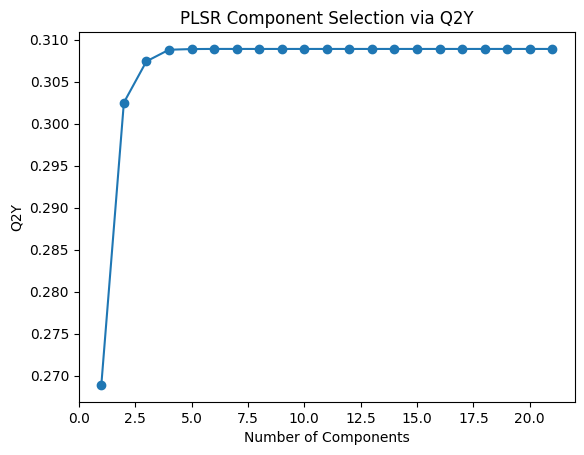

Best number of components: 6


In [14]:
#Calculate 5-fold cross-validated Q²Y scores for different numbers of PLSR components
q2y_scores = []
components = range(1, 22)

for n in components:
    pls = PLSRegression(n_components=n)
    scores = cross_val_score(pls, X_train_scaled, Y_train, cv=5, scoring='r2')
    q2y_scores.append(scores.mean())

#Plot to visually find the elbow
plt.plot(components, q2y_scores, marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Q2Y')
plt.title('PLSR Component Selection via Q2Y')
plt.show()

#Identify the component # with the highest Q2Y
best_n = components[np.argmax(q2y_scores)]
print(f"Best number of components: {best_n}")


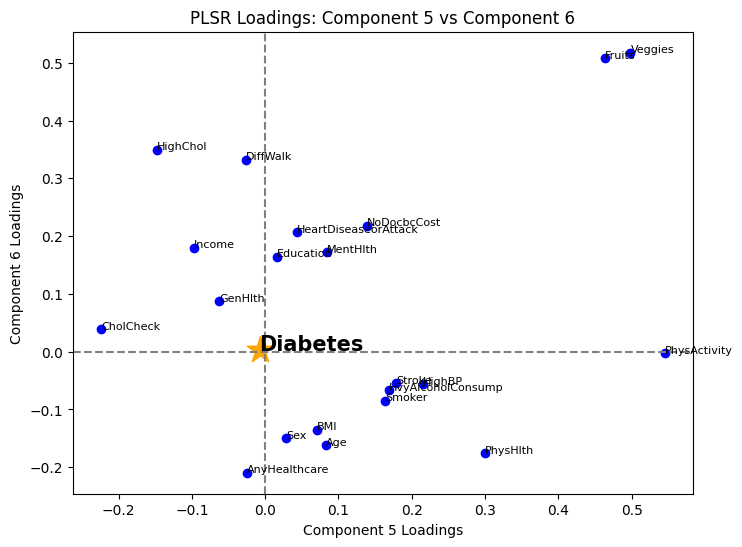

In [45]:
# Create a loadings plot for components 5 and 6 to determine whether they are
# biologically relevant.

#Fit a 6 component model
pls = PLSRegression(n_components=6)
pls.fit(X_train_scaled, Y_train)

#Get X loadings for components 5 and 6
x_loadings = pd.DataFrame(pls.x_loadings_,index=X.columns,columns=[f'Component {i+1}' for i in range(6)])

#Get Y loadings (diabetes)
y_loadings = pd.DataFrame(pls.y_loadings_, index=['Diabetes_binary'],columns=[f'Component {i+1}' for i in range(6)])

plt.figure(figsize=(8, 6))

#Plot feature variables
plt.scatter(x_loadings['Component 5'], x_loadings['Component 6'], color='blue')
for var in x_loadings.index:
    plt.annotate(var, (x_loadings['Component 5'][var], x_loadings['Component 6'][var]), fontsize=8)

#Plot diabetes
plt.scatter(y_loadings['Component 5'], y_loadings['Component 6'], color='orange', s=400, marker='*', label='Diabetes')
plt.annotate('Diabetes', (y_loadings['Component 5'].iloc[0], y_loadings['Component 6'].iloc[0]), fontsize=15, color='black', fontweight='bold')

plt.axhline(0, color='grey', linestyle='--')
plt.axvline(0, color='grey', linestyle='--')
plt.xlabel('Component 5 Loadings')
plt.ylabel('Component 6 Loadings')
plt.title('PLSR Loadings: Component 5 vs Component 6')
plt.show()

The above plot shows that the diabetes loading is near 0 on both axes. Therefore, components 5 and 6 added minimal diabetes-related information, so we proceeded with a 4-component model for final interpretation.

3. Explore PLSR with 4 components

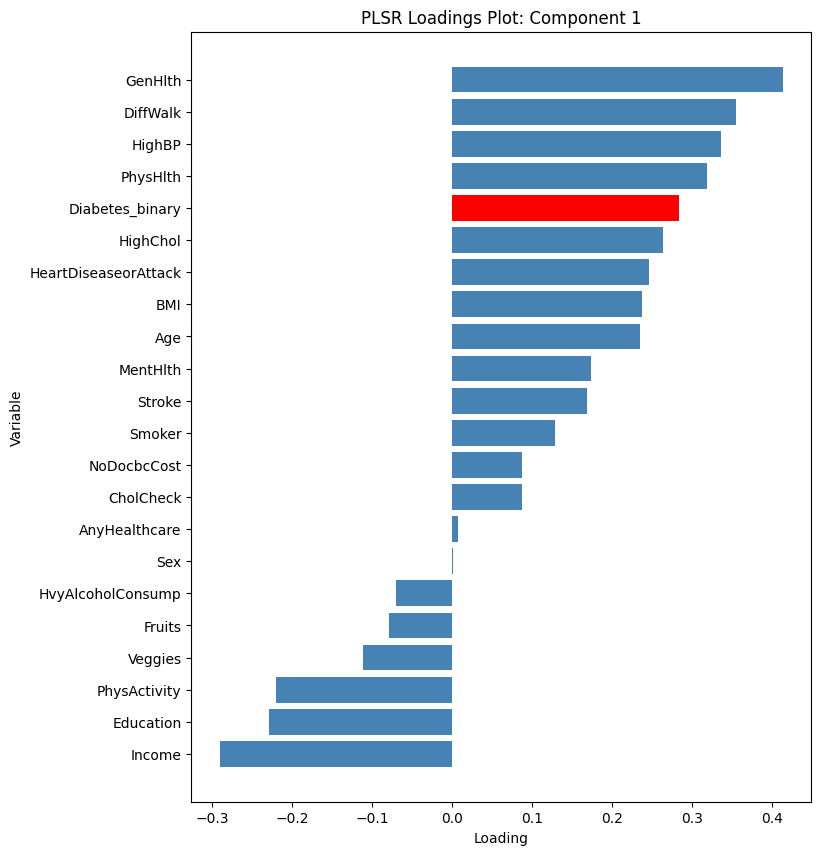

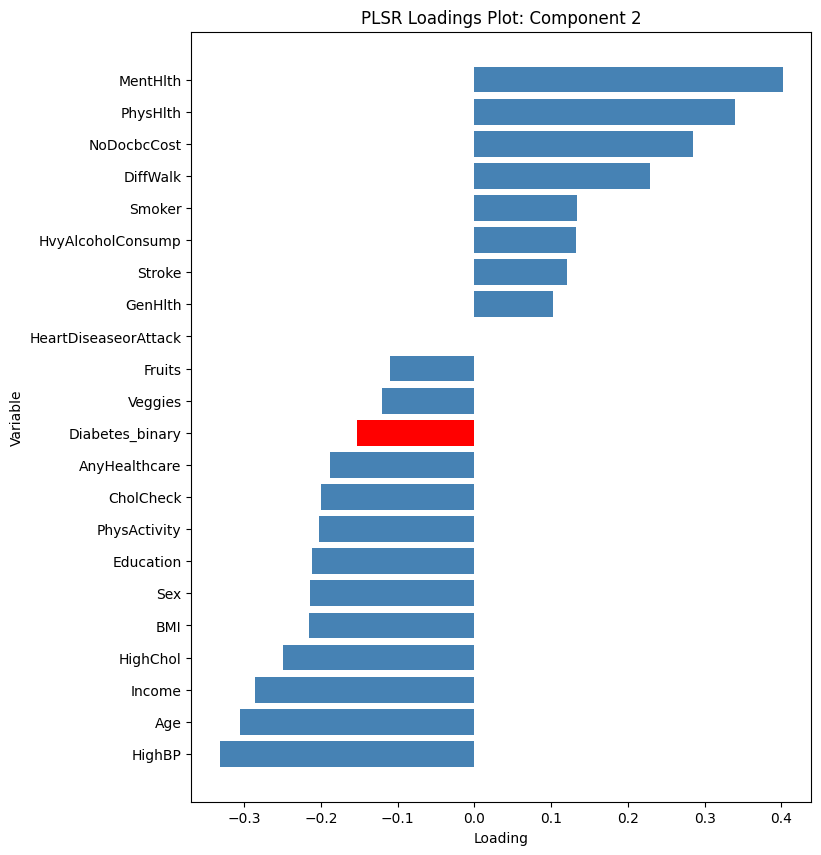

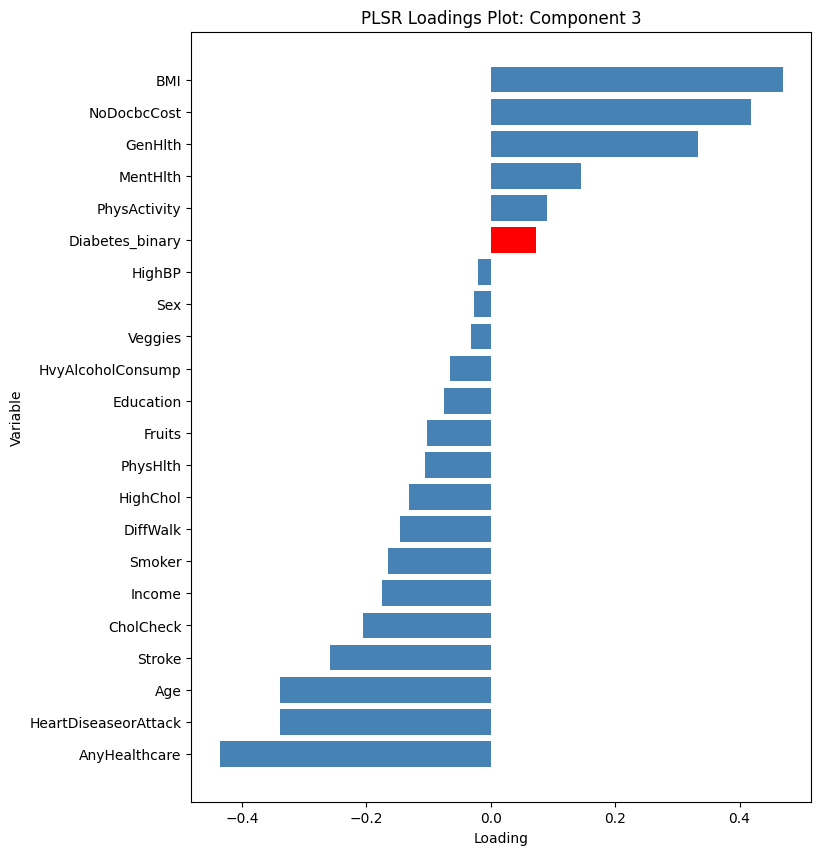

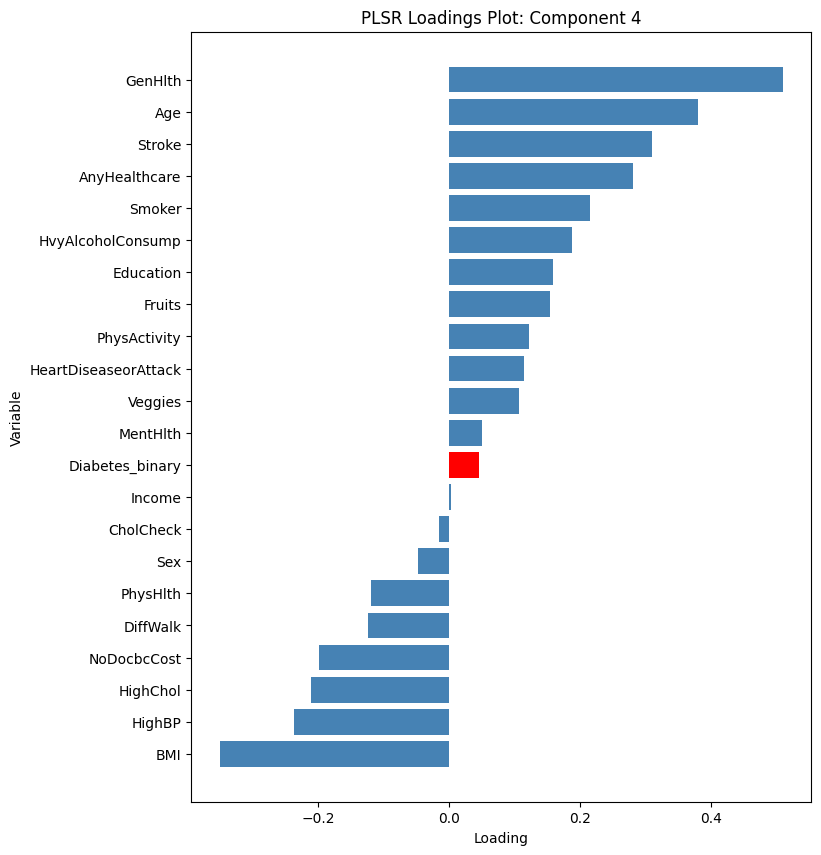

In [42]:
#Fit a 4 component model
pls = PLSRegression(n_components=4)
pls.fit(X_train_scaled, Y_train)

#Get X loadings
x_loadings = pd.DataFrame(pls_final.x_loadings_, index=X.columns, columns=[f'Component {i+1}' for i in range(4)])

#Get Y loadings
y_loadings = pd.DataFrame(pls_final.y_loadings_,index=['Diabetes_binary'],columns=[f'Component {i+1}' for i in range(4)])

#Combine X and Y loadings
all_loadings = pd.concat([x_loadings, y_loadings])

#Plot each component
for component in all_loadings.columns:
    loading_plot = all_loadings[component].sort_values()

    colors = ['red' if var == 'Diabetes_binary' else 'steelblue' for var in loading_plot.index]

    plt.figure(figsize=(8, 10))
    plt.barh(loading_plot.index, loading_plot.values, color=colors)
    plt.xlabel("Loading")
    plt.ylabel("Variable")
    plt.title(f"PLSR Loadings Plot: {component}")
    plt.show()


Components 3 and 4 had weaker diabetes loadings than Components 1 and 2, making them less useful for visual interpretation. Therefore, we will retain them in the final model but focus on the Component 1 versus Component 2 loading plot to examine the clearest diabetes-related patterns among the indicators.

4. PLSR loadings plot

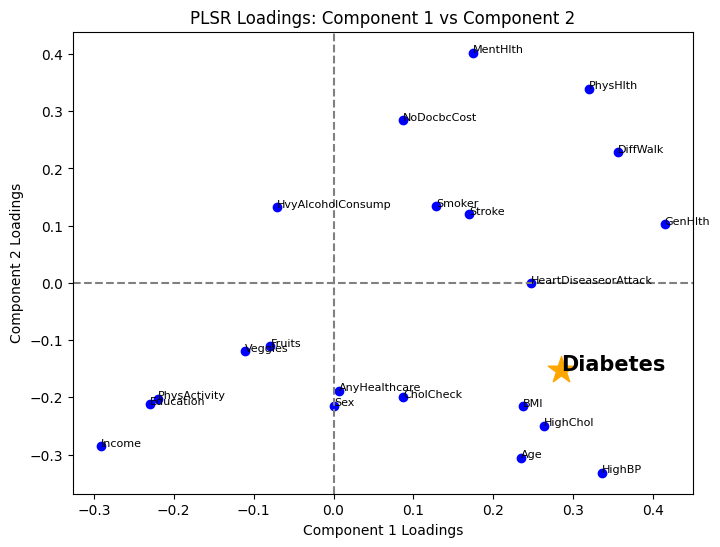

In [46]:
plt.figure(figsize=(8, 6))

#Plot feature variables
plt.scatter(x_loadings['Component 1'], x_loadings['Component 2'], color='blue')
for var in x_loadings.index:
    plt.annotate(var, (x_loadings['Component 1'][var], x_loadings['Component 2'][var]), fontsize=8)

#Plot diabetes
plt.scatter(y_loadings['Component 1'], y_loadings['Component 2'], color='orange', s=400, marker='*', label='Diabetes')
plt.annotate('Diabetes', (y_loadings['Component 1'].iloc[0], y_loadings['Component 2'].iloc[0]), fontsize=15, color='black', fontweight='bold')

plt.axhline(0, color='grey', linestyle='--')
plt.axvline(0, color='grey', linestyle='--')
plt.xlabel('Component 1 Loadings')
plt.ylabel('Component 2 Loadings')
plt.title('PLSR Loadings: Component 1 vs Component 2')
plt.show()